<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
  Residual Distribution Analysis 
</p>

#### Core & Data Libraries

In [4]:
# Core & Visualization
import os

# Set BLAS thread caps before importing NumPy/SciPy/sklearn in this kernel.
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.lines import Line2D
from IPython.display import display

# ML & Stats
from sklearn.mixture import GaussianMixture
from scipy.stats import kstest, norm, t, skewnorm, cauchy, skew, kurtosis
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

TABLE_STYLES = [
    {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "700"), ("color", "#111827"), ("text-align", "left"), ("padding", "0 0 8px 0")]},
    {"selector": "th.col_heading.level0", "props": [("background-color", "#111827"), ("color", "white"), ("font-weight", "700"), ("text-align", "center"), ("border", "1px solid #d1d5db")]},
    {"selector": "th.col_heading.level1", "props": [("background-color", "#e5e7eb"), ("color", "#111827"), ("font-weight", "700"), ("text-align", "center"), ("border", "1px solid #d1d5db")]},
    {"selector": "th.row_heading, th.blank", "props": [("background-color", "#f3f4f6"), ("color", "#111827"), ("font-weight", "700"), ("border", "1px solid #d1d5db")]},
    {"selector": "td", "props": [("border", "1px solid #e5e7eb"), ("padding", "6px 8px"), ("text-align", "right")]},
]

def display_top_table(df, caption=None, formatters=None, precision=4):
    """Display a consistently formatted notebook table with grouped headers preserved."""
    styler = df.style
    if caption:
        styler = styler.set_caption(caption)
    if formatters:
        styler = styler.format(formatters, na_rep="")
    elif precision is not None:
        styler = styler.format(precision=precision, na_rep="")

    display(
        styler
        .set_table_styles(TABLE_STYLES)
        .set_properties(**{"text-align": "right"})
    )

def format_pvalue(p, threshold=1e-16):
    p = float(p)
    if not np.isfinite(p):
        return "nan"
    return f"<{threshold:.0e}" if p < threshold else f"{p:.2e}"

#### Load OOF residuals for RF, XGB, KNN, SVR, LGBM, ANN, and RNN

In [5]:
# Load residuals for the fitted model streams used in the multi-residual analysis.
RESIDUAL_SOURCES = {
    "RF": "Residuals/residuals_RF_oof.csv",
    "XGB": "Residuals/residuals_XGB_oof.csv",
    "KNN": "Residuals/residuals_KNN_oof.csv",
    "SVR": "Residuals/residuals_SVR_oof.csv",
    "LGBM": "Residuals/residuals_LGBM_oof.csv",
    "ANN": "Residuals/residuals_ANN_oof.csv",
    "RNN": "Residuals/residuals_RNN_oof.csv",
}
MODEL_ORDER = list(RESIDUAL_SOURCES.keys())
ACTIVE_MODEL = MODEL_ORDER[0]

RESIDUAL_COLUMN_CANDIDATES = ["resid_db", "residuals", "resid", "error"]
DEVICE_COLUMN_CANDIDATES = ["device_id", "device", "ed", "ED", "node", "Device", "Node"]
LOS_COLUMN_CANDIDATES = ["los", "LoS", "LOS", "is_los"]
LOS_DEVICES = {"ED0"}

def first_existing_column(columns, candidates):
    return next((c for c in candidates if c in columns), None)

def infer_los_series(df, col_dev, col_los):
    if col_los is not None:
        los_raw = df[col_los].astype(str).str.strip().str.upper()
        return pd.Series(
            np.where(los_raw.isin(["LOS", "LINE_OF_SIGHT", "TRUE", "1", "YES"]), "LOS", "NLOS"),
            index=df.index,
            name="los",
        )

    if col_dev is not None:
        dev_norm = df[col_dev].astype(str).str.strip().str.upper()
        los_set = {d.strip().upper() for d in LOS_DEVICES}
        return pd.Series(np.where(dev_norm.isin(los_set), "LOS", "NLOS"), index=df.index, name="los")

    return None

def load_residual_stream(model_name, path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing residual file for {model_name}: {path}")

    df = pd.read_csv(path)
    res_col = first_existing_column(df.columns, RESIDUAL_COLUMN_CANDIDATES)
    if res_col is None:
        raise KeyError(f"No residual column found for {model_name}; tried {RESIDUAL_COLUMN_CANDIDATES}")

    col_dev = first_existing_column(df.columns, DEVICE_COLUMN_CANDIDATES)
    col_los = first_existing_column(df.columns, LOS_COLUMN_CANDIDATES)
    los_series = infer_los_series(df, col_dev, col_los)
    if los_series is not None:
        df["los"] = los_series

    residual_values = pd.to_numeric(df[res_col], errors="coerce").to_numpy(dtype=float)
    finite_values = residual_values[np.isfinite(residual_values)]

    meta = {
        "Model": model_name,
        "Path": path,
        "Residual column": res_col,
        "Device column": col_dev if col_dev is not None else "-",
        "LoS source column": col_los if col_los is not None else ("device rule" if col_dev is not None else "-"),
        "Rows": int(residual_values.size),
        "Finite residuals": int(finite_values.size),
        "Missing/non-finite": int(residual_values.size - finite_values.size),
    }

    if los_series is not None:
        meta["LoS count"] = int((los_series == "LOS").sum())
        meta["NLoS count"] = int((los_series == "NLOS").sum())
    else:
        meta["LoS count"] = np.nan
        meta["NLoS count"] = np.nan

    return df, residual_values, meta

residual_dfs = {}
residuals_by_model = {}
residual_meta_rows = []

for model_name, path in RESIDUAL_SOURCES.items():
    df_model, residual_values, meta = load_residual_stream(model_name, path)
    residual_dfs[model_name] = df_model
    residuals_by_model[model_name] = residual_values
    residual_meta_rows.append(meta)

residual_meta_df = pd.DataFrame(residual_meta_rows).set_index("Model")
display_top_table(
    residual_meta_df,
    caption="Loaded OOF residual streams",
    formatters={
        "Rows": "{:,.0f}",
        "Finite residuals": "{:,.0f}",
        "Missing/non-finite": "{:,.0f}",
        "LoS count": "{:,.0f}",
        "NLoS count": "{:,.0f}",
    },
)

# Backward-compatible aliases for quick one-model checks in ad hoc cells.
df_res = residual_dfs[ACTIVE_MODEL]
residuals = residuals_by_model[ACTIVE_MODEL]
n = residuals.size
print(f"Active single-model alias: {ACTIVE_MODEL} | loaded residuals: n={n:,d}")

,Path,Residual column,Device column,LoS source column,Rows,Finite residuals,Missing/non-finite,LoS count,NLoS count
Model,,,,,,,,,
RF,Residuals/residuals_RF_oof.csv,resid_db,device_id,device rule,"1,663,627","1,663,627",0,"277,295","1,386,332"
XGB,Residuals/residuals_XGB_oof.csv,resid_db,device_id,device rule,"1,663,627","1,663,627",0,"277,295","1,386,332"
KNN,Residuals/residuals_KNN_oof.csv,resid_db,device_id,device rule,"1,663,627","1,663,627",0,"277,295","1,386,332"
SVR,Residuals/residuals_SVR_oof.csv,resid_db,device_id,device rule,"150,001","150,001",0,"25,012","124,989"
LGBM,Residuals/residuals_LGBM_oof.csv,resid_db,device_id,device rule,"1,663,627","1,663,627",0,"277,295","1,386,332"
ANN,Residuals/residuals_ANN_oof.csv,resid_db,device_id,device rule,"1,663,627","1,663,627",0,"277,295","1,386,332"
RNN,Residuals/residuals_RNN_oof.csv,resid_db,device_id,device rule,"1,663,582","1,663,582",0,"277,288","1,386,294"


Active single-model alias: RF | loaded residuals: n=1,663,627


**Residual diagnostics for RF, XGB, KNN, SVR, LGBM, ANN, and RNN.**  
Omnibus and Jarque-Bera test Normality; skewness/kurtosis quantify tail behavior; Durbin-Watson checks first-order residual autocorrelation. Values near DW = 2 indicate weak autocorrelation.

In [6]:
# Normality + tail + autocorrelation checks for each residual stream.
try:
    from statsmodels.stats.stattools import omni_normtest, jarque_bera, durbin_watson
    HAS_STATSMODELS = True
except Exception:
    from scipy.stats import normaltest, jarque_bera as scipy_jarque_bera
    HAS_STATSMODELS = False

def durbin_watson_fallback(values):
    denom = np.sum(values ** 2)
    return np.nan if denom == 0 else float(np.sum(np.diff(values) ** 2) / denom)

def skew_note(value):
    if value > 0:
        return "right tail"
    if value < 0:
        return "left tail"
    return "balanced"

def kurtosis_note(value):
    if value > 0:
        return "heavy tails"
    if value < 0:
        return "light tails"
    return "normal-like tails"

def dw_note(value):
    if not np.isfinite(value):
        return "unavailable"
    if abs(value - 2.0) <= 0.10:
        return "weak autocorr."
    if value < 2.0:
        return "positive autocorr."
    return "negative autocorr."

normality_rows = []

for model_name in MODEL_ORDER:
    res = np.asarray(residuals_by_model[model_name], dtype=float)
    res = res[np.isfinite(res)]

    if HAS_STATSMODELS:
        omni_stat, omni_p = omni_normtest(res)
        jb_stat, jb_p, _, _ = jarque_bera(res)
        dw = durbin_watson(res)
    else:
        omni_stat, omni_p = normaltest(res)
        jb = scipy_jarque_bera(res)
        jb_stat, jb_p = float(jb.statistic), float(jb.pvalue)
        dw = durbin_watson_fallback(res)

    sk = float(skew(res))
    ek = float(kurtosis(res, fisher=True))

    normality_rows.append({
        "Model": model_name,
        "N": int(res.size),
        "Omnibus stat": float(omni_stat),
        "Omnibus p": format_pvalue(omni_p),
        "Jarque-Bera stat": float(jb_stat),
        "Jarque-Bera p": format_pvalue(jb_p),
        "Skewness": sk,
        "Skew note": skew_note(sk),
        "Excess kurtosis": ek,
        "Kurtosis note": kurtosis_note(ek),
        "Durbin-Watson": float(dw),
        "DW note": dw_note(dw),
    })

normality_df = pd.DataFrame(normality_rows)
normality_display = normality_df.set_index("Model")
normality_display.columns = pd.MultiIndex.from_tuples([
    ("Sample", "N"),
    ("Omnibus (D'Agostino)", "stat"),
    ("Omnibus (D'Agostino)", "p"),
    ("Jarque-Bera", "stat"),
    ("Jarque-Bera", "p"),
    ("Shape", "skewness"),
    ("Shape", "skew note"),
    ("Shape", "excess kurtosis"),
    ("Shape", "kurtosis note"),
    ("Autocorrelation", "Durbin-Watson"),
    ("Autocorrelation", "DW note"),
])

display_top_table(
    normality_display,
    caption="Residual diagnostics by model",
    formatters={
        ("Sample", "N"): "{:,.0f}",
        ("Omnibus (D'Agostino)", "stat"): "{:.2f}",
        ("Jarque-Bera", "stat"): "{:.2f}",
        ("Shape", "skewness"): "{:.3f}",
        ("Shape", "excess kurtosis"): "{:.3f}",
        ("Autocorrelation", "Durbin-Watson"): "{:.3f}",
    },
)

#### Fit Distributions and GMM Candidates for Fitted ML Models

In [7]:
# Fit distributions and GMM candidates for every residual stream.
# Downstream cells reuse: analysis_by_model, diagnostics_all, gmm_diag_all,
# selected_gmm_summary, best_fit_summary, and qq_tail_error_table.

GMM_COMPONENTS = range(1, 6)
GMM_RANDOM_STATE = 42

gmm_display_names = {
    1: "Gaussian",
    2: "2-comp. GMM",
    3: "3-comp. GMM",
    4: "4-comp. GMM",
    5: "5-comp. GMM",
}

gmm_table_names = {
    1: "Gaussian",
    2: "GMM(K=2)",
    3: "GMM(K=3)",
    4: "GMM(K=4)",
    5: "GMM(K=5)",
}

def gmm_covariances_1d(gmm_model):
    covs = gmm_model.covariances_
    if covs.ndim == 3:
        return covs[:, 0, 0]
    if covs.ndim == 2:
        return covs[:, 0]
    return covs

# Robust GMM CDF helper, shared by KS tests, tail metrics, and Q-Q plots.
def gmm_cdf(x, gmm_model):
    x = np.asarray(x, dtype=float)
    means = gmm_model.means_.ravel()
    stds = np.sqrt(gmm_covariances_1d(gmm_model))
    weights = gmm_model.weights_.ravel()

    cdf = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        cdf += w * norm.cdf(x, loc=m, scale=s)
    return cdf

def compute_aic_bic(log_likelihood, num_params, num_samples):
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(num_samples) - 2 * log_likelihood
    return aic, bic

def finite_loglik(pdf_values):
    pdf_values = np.asarray(pdf_values, dtype=float)
    return float(np.sum(np.log(np.clip(pdf_values, np.finfo(float).tiny, None))))

def gmm_num_params(k):
    # Univariate GMM: (k - 1) weights + k means + k variances.
    return 3 * k - 1

analysis_by_model = {}
diagnostic_frames = []
gmm_diag_frames = []
selected_gmm_rows = []
best_fit_rows = []

for model_name in MODEL_ORDER:
    res = np.asarray(residuals_by_model[model_name], dtype=float)
    res = res[np.isfinite(res)]
    if res.size == 0:
        raise ValueError(f"No finite residuals available for {model_name}")

    n = res.size
    residuals_array = res.reshape(-1, 1)
    sorted_residuals = np.sort(res)
    probabilities = (np.arange(1, n + 1) - 0.5) / n

    # 1. Normal distribution
    normal_params = norm.fit(res)
    loc_norm, scale_norm = normal_params
    normal_dist = norm(loc=loc_norm, scale=scale_norm)

    # 2. Skew-normal distribution
    skew_params = skewnorm.fit(res)
    shape_sn, loc_sn, scale_sn = skew_params
    skew_dist = skewnorm(shape_sn, loc=loc_sn, scale=scale_sn)

    # 3. Cauchy distribution
    cauchy_params = cauchy.fit(res)
    cauchy_dist = cauchy(*cauchy_params)

    # 4. Student's t distribution
    t_params = t.fit(res)
    df_t, loc_t, scale_t = t_params
    t_dist = t(df=df_t, loc=loc_t, scale=scale_t)

    # 5. GMM candidates.
    gmm_components = list(GMM_COMPONENTS)
    gmm_models = [
        GaussianMixture(n_components=k, random_state=GMM_RANDOM_STATE).fit(residuals_array)
        for k in gmm_components
    ]
    gmm_models_by_component = dict(zip(gmm_components, gmm_models))

    gmm_diagnostics = []
    for k, gmm_k in zip(gmm_components, gmm_models):
        loglik_k = float(np.sum(gmm_k.score_samples(residuals_array)))
        aic_k, bic_k = compute_aic_bic(loglik_k, gmm_num_params(k), n)
        ks_k = kstest(res, lambda x, model=gmm_k: gmm_cdf(x, model))

        gmm_diagnostics.append({
            "Model": model_name,
            "GMM Components": k,
            "Model Label": gmm_display_names[k],
            "Log-Likelihood": loglik_k,
            "AIC": aic_k,
            "BIC": bic_k,
            "KS Statistic": float(ks_k.statistic),
            "KS p-value": float(ks_k.pvalue),
        })

    gmm_diag_df = pd.DataFrame(gmm_diagnostics)
    best_gmm_row = gmm_diag_df.loc[gmm_diag_df["BIC"].idxmin()]
    best_gmm_components = int(best_gmm_row["GMM Components"])
    best_gmm = gmm_models_by_component[best_gmm_components]
    best_gmm_display_name = gmm_display_names[best_gmm_components]
    best_gmm_table_name = gmm_table_names[best_gmm_components]

    loglik_norm = finite_loglik(normal_dist.pdf(res))
    aic_norm, bic_norm = compute_aic_bic(loglik_norm, 2, n)
    ks_norm = kstest(res, normal_dist.cdf)

    loglik_sn = finite_loglik(skew_dist.pdf(res))
    aic_sn, bic_sn = compute_aic_bic(loglik_sn, 3, n)
    ks_sn = kstest(res, skew_dist.cdf)

    loglik_cauchy = finite_loglik(cauchy_dist.pdf(res))
    aic_cauchy, bic_cauchy = compute_aic_bic(loglik_cauchy, 2, n)
    ks_cauchy = kstest(res, cauchy_dist.cdf)

    loglik_t = finite_loglik(t_dist.pdf(res))
    aic_t, bic_t = compute_aic_bic(loglik_t, 3, n)
    ks_t = kstest(res, t_dist.cdf)

    loglik_gmm = float(best_gmm_row["Log-Likelihood"])
    aic_gmm = float(best_gmm_row["AIC"])
    bic_gmm = float(best_gmm_row["BIC"])
    ks_gmm = kstest(res, lambda x, model=best_gmm: gmm_cdf(x, model))

    diagnostics = pd.DataFrame({
        "Model": [model_name] * 5,
        "Distribution": [
            "Normal",
            "Skew-Normal",
            f"Best GMM ({best_gmm_display_name})",
            "Cauchy",
            "t-Distribution",
        ],
        "Log-Likelihood": [loglik_norm, loglik_sn, loglik_gmm, loglik_cauchy, loglik_t],
        "AIC": [aic_norm, aic_sn, aic_gmm, aic_cauchy, aic_t],
        "BIC": [bic_norm, bic_sn, bic_gmm, bic_cauchy, bic_t],
        "KS Test Statistic": [ks_norm.statistic, ks_sn.statistic, ks_gmm.statistic, ks_cauchy.statistic, ks_t.statistic],
        "KS Test p-value": [ks_norm.pvalue, ks_sn.pvalue, ks_gmm.pvalue, ks_cauchy.pvalue, ks_t.pvalue],
    })

    best_fit = diagnostics.loc[diagnostics["KS Test Statistic"].idxmin()]

    analysis_by_model[model_name] = {
        "res": res,
        "n": n,
        "residuals_array": residuals_array,
        "sorted_residuals": sorted_residuals,
        "probabilities": probabilities,
        "normal_params": normal_params,
        "normal_dist": normal_dist,
        "skew_params": skew_params,
        "skew_dist": skew_dist,
        "cauchy_params": cauchy_params,
        "cauchy_dist": cauchy_dist,
        "t_params": t_params,
        "t_dist": t_dist,
        "gmm_models": gmm_models,
        "gmm_components": gmm_components,
        "gmm_models_by_component": gmm_models_by_component,
        "gmm_diag_df": gmm_diag_df,
        "best_gmm_row": best_gmm_row,
        "best_gmm_components": best_gmm_components,
        "best_gmm": best_gmm,
        "best_gmm_display_name": best_gmm_display_name,
        "best_gmm_table_name": best_gmm_table_name,
        "diagnostics": diagnostics,
        "best_fit": best_fit,
    }

    selected_gmm_rows.append({
        "Model": model_name,
        "Selected GMM": best_gmm_display_name,
        "GMM Components": best_gmm_components,
        "BIC": float(best_gmm_row["BIC"]),
    })

    best_fit_rows.append({
        "Model": model_name,
        "Best Fit (KS)": best_fit["Distribution"],
        "KS Test Statistic": float(best_fit["KS Test Statistic"]),
        "KS Test p-value": float(best_fit["KS Test p-value"]),
    })

    gmm_diag_frames.append(gmm_diag_df)
    diagnostic_frames.append(diagnostics)

gmm_diag_all = pd.concat(gmm_diag_frames, ignore_index=True)
diagnostics_all = pd.concat(diagnostic_frames, ignore_index=True)
selected_gmm_summary = pd.DataFrame(selected_gmm_rows).set_index("Model")
best_fit_summary = pd.DataFrame(best_fit_rows).set_index("Model")

# Backward-compatible aliases for the active model.
active_state = analysis_by_model[ACTIVE_MODEL]
res = active_state["res"]
residuals_array = active_state["residuals_array"]
sorted_residuals = active_state["sorted_residuals"]
probabilities = active_state["probabilities"]
normal_dist = active_state["normal_dist"]
skew_dist = active_state["skew_dist"]
cauchy_dist = active_state["cauchy_dist"]
t_dist = active_state["t_dist"]
gmm_models = active_state["gmm_models"]
best_gmm = active_state["best_gmm"]
best_gmm_display_name = active_state["best_gmm_display_name"]
best_gmm_table_name = active_state["best_gmm_table_name"]

display_top_table(
    selected_gmm_summary,
    caption="BIC-selected GMM by residual model",
    formatters={"GMM Components": "{:,.0f}", "BIC": "{:,.2f}"},
)

display_top_table(
    diagnostics_all.set_index(["Model", "Distribution"]),
    caption="Distribution diagnostics by residual model",
    formatters={
        "Log-Likelihood": "{:,.2f}",
        "AIC": "{:,.2f}",
        "BIC": "{:,.2f}",
        "KS Test Statistic": "{:.4f}",
        "KS Test p-value": "{:.4g}",
    },
)

display_top_table(
    best_fit_summary,
    caption="Best fit by residual model based on KS test statistic",
    formatters={"KS Test Statistic": "{:.4f}", "KS Test p-value": "{:.4g}"},
)

,Selected GMM,GMM Components,BIC
Model,,,
RF,3-comp. GMM,3,"10,393,350.02"
XGB,5-comp. GMM,5,"10,343,938.37"
KNN,3-comp. GMM,3,"10,831,818.91"
SVR,3-comp. GMM,3,"966,669.90"
LGBM,3-comp. GMM,3,"10,374,696.68"
ANN,3-comp. GMM,3,"10,531,883.52"
RNN,3-comp. GMM,3,"10,582,523.64"


,Best Fit (KS),KS Test Statistic,KS Test p-value
Model,,,
RF,Best GMM (3-comp. GMM),0.0112,1.208e-181
XGB,Best GMM (5-comp. GMM),0.0069,2.405e-69
KNN,Best GMM (3-comp. GMM),0.0058,2.543e-48
SVR,Best GMM (3-comp. GMM),0.0061,2.789e-05
LGBM,Best GMM (3-comp. GMM),0.0076,6.125e-85
ANN,Best GMM (3-comp. GMM),0.0062,3.055e-56
RNN,Best GMM (3-comp. GMM),0.0088,4.954e-112


#### GMM Diagnostics (1–5 components)

In [8]:
# GMM diagnostics table from the models fitted in the distribution-fit cell.

display_top_table(
    gmm_diag_all.set_index(["Model", "GMM Components", "Model Label"]),
    caption="GMM diagnostics by residual model",
    formatters={
        "Log-Likelihood": "{:,.2f}",
        "AIC": "{:,.2f}",
        "BIC": "{:,.2f}",
        "KS Statistic": "{:.4f}",
        "KS p-value": "{:.4g}",
    },
)

display_top_table(
    selected_gmm_summary,
    caption="Best GMM model based on lowest BIC",
    formatters={"GMM Components": "{:,.0f}", "BIC": "{:,.2f}"},
)

,Selected GMM,GMM Components,BIC
Model,,,
RF,3-comp. GMM,3,"10,393,350.02"
XGB,5-comp. GMM,5,"10,343,938.37"
KNN,3-comp. GMM,3,"10,831,818.91"
SVR,3-comp. GMM,3,"966,669.90"
LGBM,3-comp. GMM,3,"10,374,696.68"
ANN,3-comp. GMM,3,"10,531,883.52"
RNN,3-comp. GMM,3,"10,582,523.64"


In [9]:
# Q-Q tail error metrics for fitted parametric distributions and all GMM candidates.

TAIL_PROB_LOW = 0.05
TAIL_PROB_HIGH = 0.95
N_QQ_TAIL_POINTS = 200
PPF_GRID_SIZE = 50_000

QQ_LINEWIDTH = 2
QQ_LEGEND_MARKER_SIZE = 7
QQ_TAIL_BOX_POS = (0.08, 0.76)
SUBPLOT_LABELS = [f"({chr(97 + i)})" for i in range(26)]
TAIL_ORDER = ["both", "lower", "upper"]

p_low = np.linspace(0.001, TAIL_PROB_LOW, N_QQ_TAIL_POINTS)
p_high = np.linspace(TAIL_PROB_HIGH, 0.999, N_QQ_TAIL_POINTS)

def qq_tail_metrics(empirical_q, model_q):
    err = empirical_q - model_q
    return {
        "tail_rmse": float(np.sqrt(np.mean(err ** 2))),
        "tail_mae": float(np.mean(np.abs(err))),
        "tail_bias": float(np.mean(err)),
        "tail_max_abs": float(np.max(np.abs(err))),
    }

def gmm_ppf_from_existing_cdf(p_grid, gmm_model, reference_values):
    ref = np.asarray(reference_values, dtype=float)

    means = gmm_model.means_.ravel()
    stds = np.sqrt(gmm_covariances_1d(gmm_model))

    lo = min(ref.min(), np.min(means - 8 * stds))
    hi = max(ref.max(), np.max(means + 8 * stds))

    x_grid = np.linspace(lo, hi, PPF_GRID_SIZE)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, gmm_model))

    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]

    return np.interp(p_grid, unique_cdf, unique_x)

def qq_legend(ax, title, color):
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=color,
            markeredgecolor="k",
            markersize=QQ_LEGEND_MARKER_SIZE,
            label="Empirical residual quantiles",
        ),
        Line2D(
            [0], [0],
            color="r",
            linestyle="--",
            linewidth=QQ_LINEWIDTH,
            label=r"Reference ($y=x$)",
        ),
    ]
    leg = ax.legend(handles=handles, loc="lower right", frameon=False, title=rf"{title} fit")
    leg.get_title().set_fontstyle("italic")
    leg.get_title().set_fontweight("bold")

def add_tail_error_text(ax, model_name, table_name, tail_error_table, pos=QQ_TAIL_BOX_POS):
    row = tail_error_table[
        (tail_error_table["Model"] == model_name)
        & (tail_error_table["distribution"] == table_name)
        & (tail_error_table["tail"] == "both")
    ]

    if row.empty:
        return

    row = row.iloc[0]
    txt = f"Tail RMSE = {row['tail_rmse']:.2f} dB\nBias = {row['tail_bias']:.2f} dB"

    ax.text(
        pos[0], pos[1], txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.5", alpha=0.85),
        zorder=10,
    )

tail_error_rows = []

tail_grids = {
    "lower": p_low,
    "upper": p_high,
    "both": np.r_[p_low, p_high],
}

for model_name in MODEL_ORDER:
    state = analysis_by_model[model_name]
    res = state["res"]

    fitted_distributions = {
        "Normal": state["normal_dist"],
        "SkewNormal": state["skew_dist"],
        "Cauchy": state["cauchy_dist"],
        "StudentT": state["t_dist"],
    }

    for tail_name, p_grid in tail_grids.items():
        empirical_q = np.quantile(res, p_grid)

        for dist_name, dist_obj in fitted_distributions.items():
            model_q = dist_obj.ppf(p_grid)
            metrics = qq_tail_metrics(empirical_q, model_q)

            tail_error_rows.append({
                "Model": model_name,
                "distribution": dist_name,
                "tail": tail_name,
                "p_min": float(np.min(p_grid)),
                "p_max": float(np.max(p_grid)),
                "n_quantile_points": len(p_grid),
                **metrics,
            })

        for k, gmm_model in zip(state["gmm_components"], state["gmm_models"]):
            model_q = gmm_ppf_from_existing_cdf(p_grid, gmm_model, res)
            metrics = qq_tail_metrics(empirical_q, model_q)

            tail_error_rows.append({
                "Model": model_name,
                "distribution": gmm_table_names[k],
                "tail": tail_name,
                "p_min": float(np.min(p_grid)),
                "p_max": float(np.max(p_grid)),
                "n_quantile_points": len(p_grid),
                **metrics,
            })

qq_tail_error_table = pd.DataFrame(tail_error_rows)
qq_tail_error_table["_model_order"] = qq_tail_error_table["Model"].map({name: i for i, name in enumerate(MODEL_ORDER)})
qq_tail_error_table["_tail_order"] = qq_tail_error_table["tail"].map({name: i for i, name in enumerate(TAIL_ORDER)})
qq_tail_error_table = (
    qq_tail_error_table
    .sort_values(["_model_order", "_tail_order", "tail_rmse"])
    .drop(columns=["_model_order", "_tail_order"])
    .reset_index(drop=True)
)

display_top_table(
    qq_tail_error_table.set_index(["Model", "tail", "distribution"]),
    caption="Q-Q tail error metrics by residual model",
    formatters={
        "p_min": "{:.3f}",
        "p_max": "{:.3f}",
        "n_quantile_points": "{:,.0f}",
        "tail_rmse": "{:.5f}",
        "tail_mae": "{:.5f}",
        "tail_bias": "{:.5f}",
        "tail_max_abs": "{:.5f}",
    },
)

#### GMM Model-Selection Plots Across Residual Models

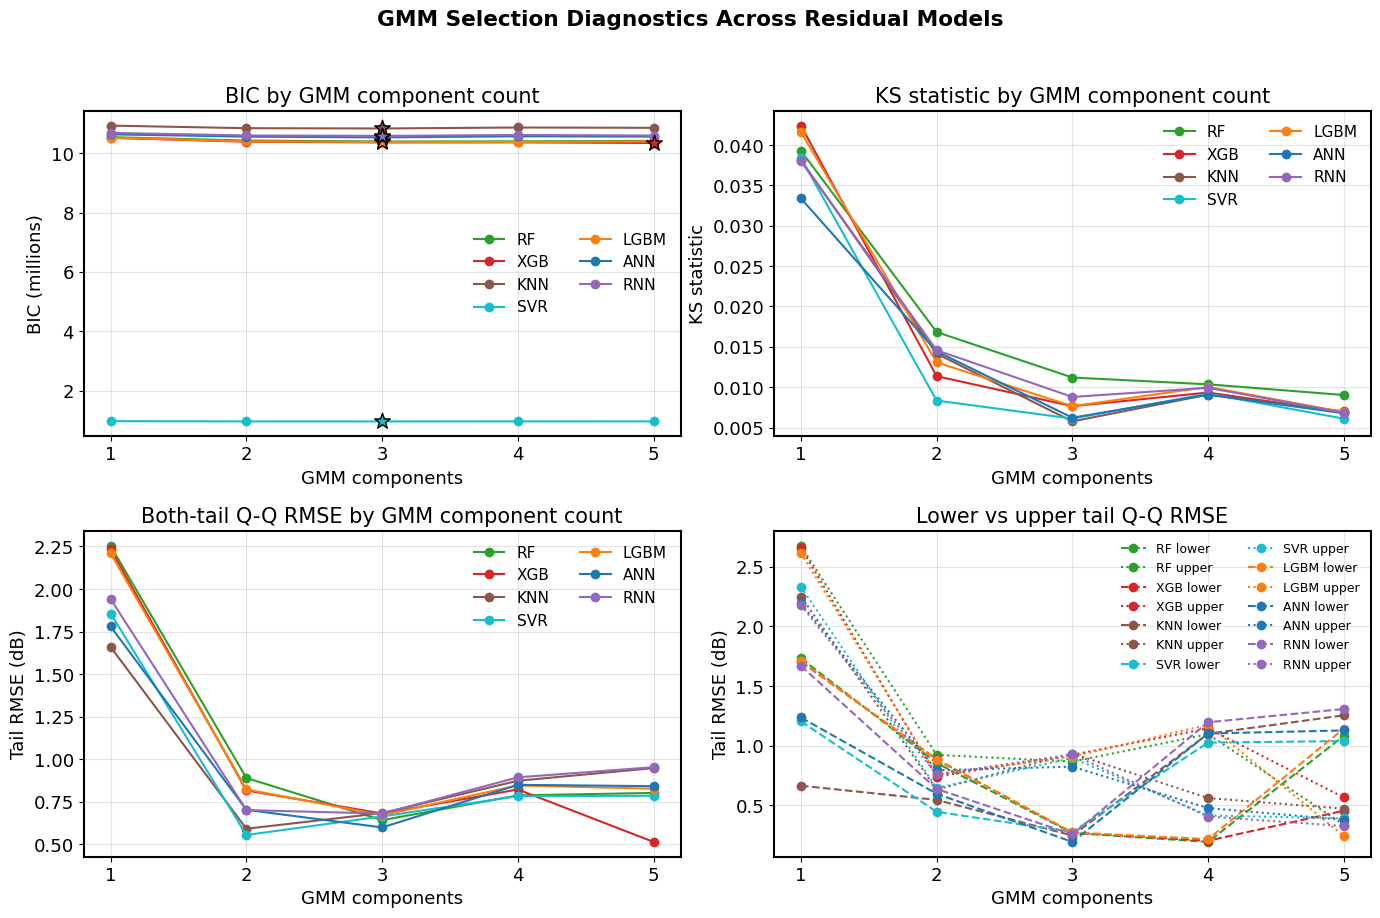

In [10]:
# GMM model-selection comparison across residual streams.
# This replaces the single-model 1-to-5 GMM Q-Q panel with selection diagnostics that scale to all fitted models.

plt.rcParams.update({"font.size": 13, "axes.titlesize": 15, "axes.labelsize": 13, "legend.fontsize": 11})

MODEL_COLORS = {"RF": "#2ca02c", "XGB": "#d62728", "KNN": "#8c564b", "SVR": "#17becf", "LGBM": "#ff7f0e", "ANN": "#1f77b4", "RNN": "#9467bd"}
TAIL_LINESTYLES = {"lower": "--", "upper": ":"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

def gmm_tail_curve(model_name, tail_name):
    rows = qq_tail_error_table[
        (qq_tail_error_table["Model"] == model_name)
        & (qq_tail_error_table["tail"] == tail_name)
    ]

    curve_rows = []
    for _, row in rows.iterrows():
        label = row["distribution"]
        if label == "Gaussian":
            k = 1
        elif label.startswith("GMM(K="):
            k = int(label.split("K=")[1].split(")")[0])
        else:
            continue
        curve_rows.append({"K": k, "tail_rmse": row["tail_rmse"]})

    return pd.DataFrame(curve_rows).sort_values("K")

for model_name in MODEL_ORDER:
    state = analysis_by_model[model_name]
    color = MODEL_COLORS.get(model_name, "#4b5563")
    gmm_df = state["gmm_diag_df"]

    axes[0].plot(gmm_df["GMM Components"], gmm_df["BIC"] / 1e6, marker="o", color=color, label=model_name)
    axes[0].scatter(
        [state["best_gmm_components"]],
        [float(state["best_gmm_row"]["BIC"]) / 1e6],
        s=140,
        marker="*",
        color=color,
        edgecolor="black",
        zorder=5,
    )

    axes[1].plot(gmm_df["GMM Components"], gmm_df["KS Statistic"], marker="o", color=color, label=model_name)

    both_curve = gmm_tail_curve(model_name, "both")
    axes[2].plot(both_curve["K"], both_curve["tail_rmse"], marker="o", color=color, label=model_name)

    for tail_name in ["lower", "upper"]:
        curve = gmm_tail_curve(model_name, tail_name)
        axes[3].plot(
            curve["K"],
            curve["tail_rmse"],
            marker="o",
            color=color,
            linestyle=TAIL_LINESTYLES[tail_name],
            label=f"{model_name} {tail_name}",
        )

axes[0].set_title("BIC by GMM component count")
axes[0].set_ylabel("BIC (millions)")
axes[0].set_xlabel("GMM components")
axes[0].legend(frameon=False, ncol=2)

axes[1].set_title("KS statistic by GMM component count")
axes[1].set_ylabel("KS statistic")
axes[1].set_xlabel("GMM components")
axes[1].legend(frameon=False, ncol=2)

axes[2].set_title("Both-tail Q-Q RMSE by GMM component count")
axes[2].set_ylabel("Tail RMSE (dB)")
axes[2].set_xlabel("GMM components")
axes[2].legend(frameon=False, ncol=2)

axes[3].set_title("Lower vs upper tail Q-Q RMSE")
axes[3].set_ylabel("Tail RMSE (dB)")
axes[3].set_xlabel("GMM components")
axes[3].legend(frameon=False, ncol=2, fontsize=9)

for ax in axes:
    ax.set_xticks(list(GMM_COMPONENTS))
    ax.grid(True, alpha=0.35)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

fig.suptitle("GMM Selection Diagnostics Across Residual Models", fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("Figures/gmm_selection_multi_residuals.png", dpi=600, bbox_inches="tight")
plt.show()

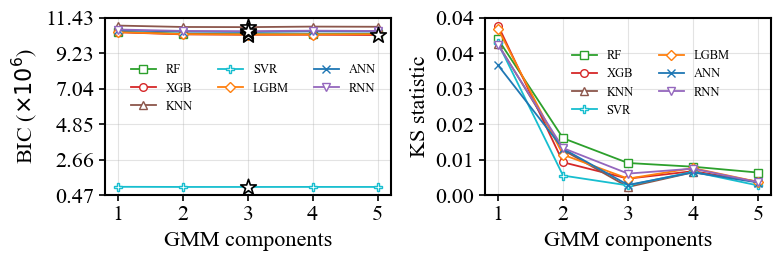

In [11]:
# BIC and KS model-selection plots 

LABEL_FONTSIZE = 16
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 9
Y_TICKS_BIC = 6
Y_TICKS_KS = 6

MODEL_MARKERS = {"RF": "s", "XGB": "o", "KNN": "^", "SVR": "P", "LGBM": "D", "ANN": "x", "RNN": "v"}

plt.rcParams.update({"font.family": "Times New Roman", "axes.labelsize": LABEL_FONTSIZE, "xtick.labelsize": TICK_FONTSIZE, "ytick.labelsize": TICK_FONTSIZE, "legend.fontsize": LEGEND_FONTSIZE})

fig, axes = plt.subplots(1, 2, figsize=(8, 2.8))

for model_name in MODEL_ORDER:
    state = analysis_by_model[model_name]
    color = MODEL_COLORS.get(model_name, "#4b5563")
    gmm_df = state["gmm_diag_df"]

    marker = MODEL_MARKERS.get(model_name, "o")

    axes[0].plot(gmm_df["GMM Components"], gmm_df["BIC"] / 1e6, marker=marker, linestyle="-", color=color, markerfacecolor="white", markeredgecolor=color, linewidth=1.3, markersize=5.5, label=model_name)
    axes[0].scatter([state["best_gmm_components"]], [float(state["best_gmm_row"]["BIC"]) / 1e6], s=140, marker="*", facecolor="white", edgecolor="black", linewidth=1.2, zorder=5)

    axes[1].plot(gmm_df["GMM Components"], gmm_df["KS Statistic"], marker=marker, linestyle="-", color=color, markerfacecolor="white", markeredgecolor=color, linewidth=1.3, markersize=5.5, label=model_name)

axes[0].set_ylabel(r"BIC ($\times 10^6$)", fontsize=LABEL_FONTSIZE)
axes[0].set_xlabel("GMM components", fontsize=LABEL_FONTSIZE)
axes[0].legend(frameon=False, ncol=3, fontsize=LEGEND_FONTSIZE, loc="upper center", bbox_to_anchor=(0.52, 0.80))

axes[1].set_ylabel("KS statistic", fontsize=LABEL_FONTSIZE)
axes[1].set_xlabel("GMM components", fontsize=LABEL_FONTSIZE)
axes[1].legend(frameon=False, ncol=2, fontsize=LEGEND_FONTSIZE, loc="upper center", bbox_to_anchor=(0.58, 0.88))

axes[0].yaxis.set_major_locator(LinearLocator(numticks=Y_TICKS_BIC))
axes[1].yaxis.set_major_locator(LinearLocator(numticks=Y_TICKS_KS))
axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

for ax in axes:
    ax.set_xticks(list(GMM_COMPONENTS))
    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE, width=1.2, length=4)
    ax.grid(True, alpha=0.35)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

plt.tight_layout()

os.makedirs("Figures", exist_ok=True)
plt.savefig("Figures/gmm_bic_ks_multi_residuals.png", dpi=600, bbox_inches="tight")
plt.show()

#### Distribution Parameters by Residual Model

In [12]:
# Distribution parameters, including the BIC-selected GMM for each residual stream.

param_rows = []

def add_param_rows(model_name, distribution, component, params):
    for name, value in params:
        param_rows.append({
            "Model": model_name,
            "Distribution": distribution,
            "Component": component,
            "Parameter": name,
            "Value": float(value),
        })

for model_name in MODEL_ORDER:
    state = analysis_by_model[model_name]

    loc_norm, scale_norm = state["normal_params"]
    shape_sn, loc_sn, scale_sn = state["skew_params"]
    cauchy_params = state["cauchy_params"]
    df_t, loc_t, scale_t = state["t_params"]
    best_gmm = state["best_gmm"]

    add_param_rows(model_name, "Normal", "all", [("Mean", loc_norm), ("Std", scale_norm)])
    add_param_rows(model_name, "Skew-Normal", "all", [("Shape", shape_sn), ("Location", loc_sn), ("Scale", scale_sn)])
    add_param_rows(model_name, "Cauchy", "all", [("Location", cauchy_params[0]), ("Scale", cauchy_params[1])])
    add_param_rows(model_name, "t-Distribution", "all", [("Degrees of Freedom", df_t), ("Location", loc_t), ("Scale", scale_t)])

    covs = gmm_covariances_1d(best_gmm)
    gmm_label = f"Best GMM ({state['best_gmm_display_name']})"
    for i in range(best_gmm.n_components):
        add_param_rows(
            model_name,
            gmm_label,
            str(i + 1),
            [
                ("Weight", best_gmm.weights_[i]),
                ("Mean", best_gmm.means_[i, 0]),
                ("Std", np.sqrt(covs[i])),
            ],
        )

parameter_table = pd.DataFrame(param_rows)

display_top_table(
    parameter_table.set_index(["Model", "Distribution", "Component", "Parameter"]),
    caption="Distribution parameters by residual model",
    formatters={"Value": "{:.4f}"},
)

#### Final Multi-Residual Diagnostic Plots

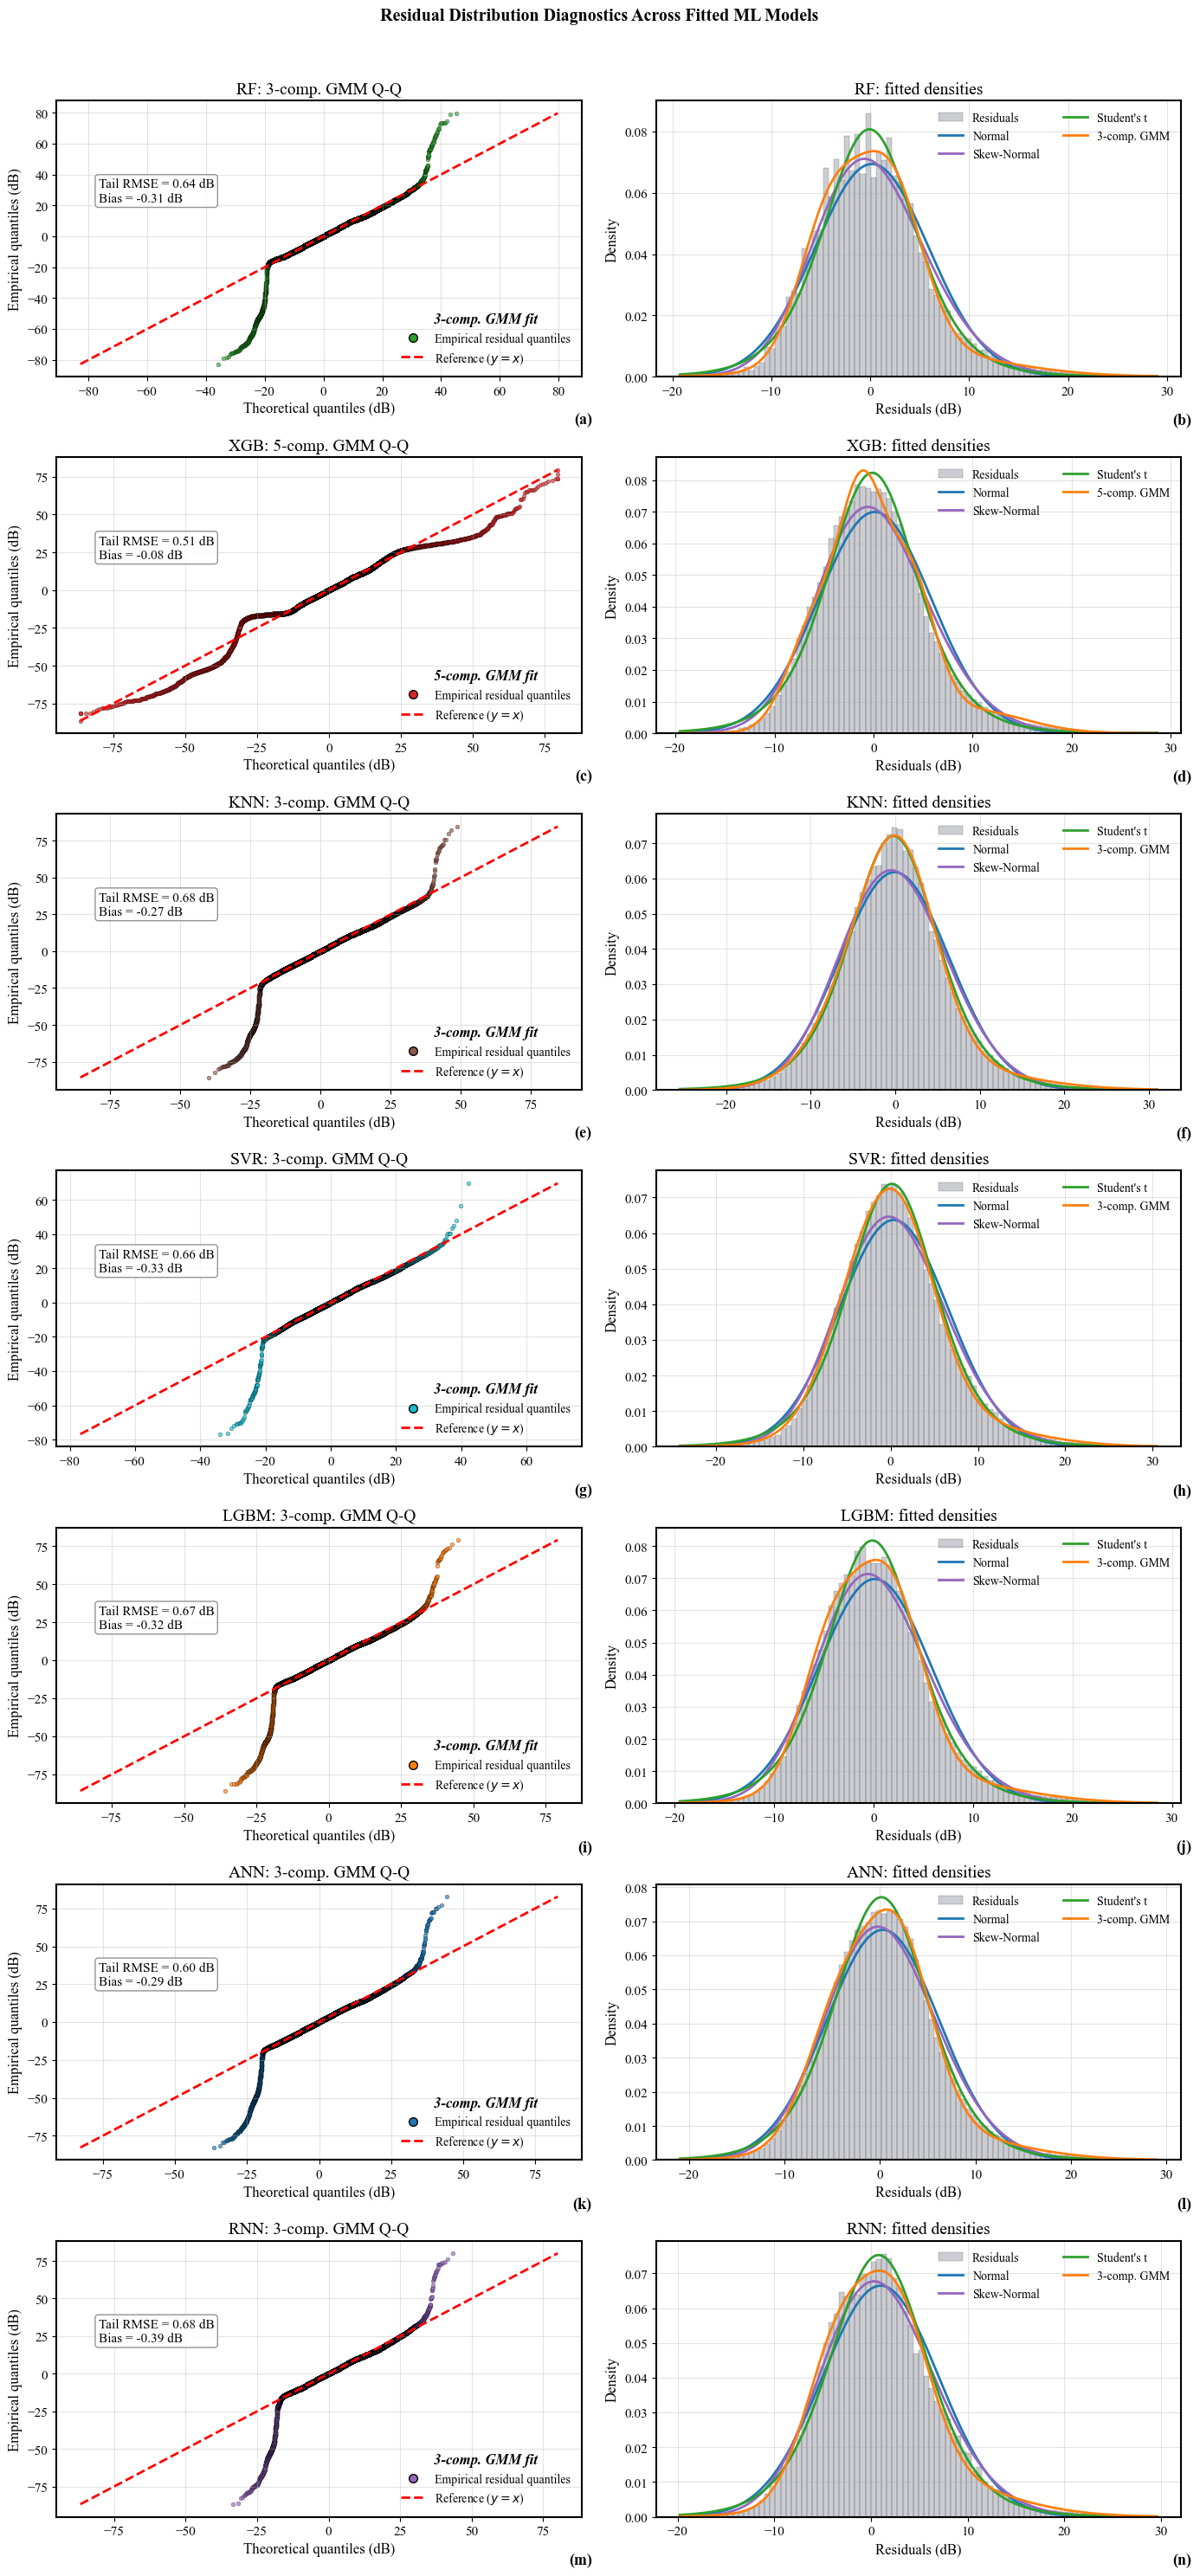

In [13]:
# Final multi-residual diagnostic plots.
# Left column: BIC-selected GMM Q-Q plot per model.
# Right column: residual histogram with fitted density overlays per model.

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

DIAG_QQ_POINT_SIZE = 12
GMM_QQ_GRID_POINTS = 200_000
DENSITY_GRID_POINTS = 1_200
DIST_COLORS = {
    "Residuals": "#6b7280",
    "Normal": "#1f77b4",
    "Skew-Normal": "#9467bd",
    "Student's t": "#2ca02c",
    "Best GMM": "#ff7f0e",
}
MODEL_COLORS = {"RF": "#2ca02c", "XGB": "#d62728", "KNN": "#8c564b", "SVR": "#17becf", "LGBM": "#ff7f0e", "ANN": "#1f77b4", "RNN": "#9467bd"}

fig, axes = plt.subplots(len(MODEL_ORDER), 2, figsize=(14, 4.2 * len(MODEL_ORDER)), squeeze=False)

def robust_plot_limits(values, lower=0.001, upper=0.999, pad_frac=0.08):
    lo, hi = np.quantile(values, [lower, upper])
    pad = max((hi - lo) * pad_frac, 1e-6)
    return lo - pad, hi + pad

def plot_best_gmm_qq(ax, model_name, state):
    res = state["res"]
    sorted_residuals = state["sorted_residuals"]
    probabilities = state["probabilities"]
    color = MODEL_COLORS.get(model_name, "#4b5563")

    x_grid = np.linspace(res.min(), res.max(), GMM_QQ_GRID_POINTS)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, state["best_gmm"]))
    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]
    ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
    theoretical_q = ppf_func(probabilities)

    ax.scatter(
        theoretical_q,
        sorted_residuals,
        s=DIAG_QQ_POINT_SIZE,
        edgecolors="k",
        linewidths=0.25,
        facecolor=color,
        alpha=0.65,
    )

    min_val = min(theoretical_q.min(), sorted_residuals.min())
    max_val = max(theoretical_q.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=QQ_LINEWIDTH)
    ax.set_xlabel("Theoretical quantiles (dB)")
    ax.set_ylabel("Empirical quantiles (dB)")
    ax.set_title(f"{model_name}: {state['best_gmm_display_name']} Q-Q")
    ax.grid(True, alpha=0.35)
    qq_legend(ax, state["best_gmm_display_name"], color)
    add_tail_error_text(ax, model_name, state["best_gmm_table_name"], qq_tail_error_table, pos=(0.08, 0.72))

def plot_density_overlay(ax, model_name, state):
    res = state["res"]
    x_min, x_max = robust_plot_limits(res)
    x_vals = np.linspace(x_min, x_max, DENSITY_GRID_POINTS)

    ax.hist(
        res,
        bins=90,
        range=(x_min, x_max),
        density=True,
        alpha=0.35,
        color=DIST_COLORS["Residuals"],
        edgecolor="black",
        linewidth=0.35,
        label="Residuals",
    )

    ax.plot(x_vals, state["normal_dist"].pdf(x_vals), label="Normal", color=DIST_COLORS["Normal"], linewidth=QQ_LINEWIDTH)
    ax.plot(x_vals, state["skew_dist"].pdf(x_vals), label="Skew-Normal", color=DIST_COLORS["Skew-Normal"], linewidth=QQ_LINEWIDTH)
    ax.plot(x_vals, state["t_dist"].pdf(x_vals), label="Student's t", color=DIST_COLORS["Student's t"], linewidth=QQ_LINEWIDTH)

    gmm_density = np.exp(state["best_gmm"].score_samples(x_vals.reshape(-1, 1)))
    ax.plot(x_vals, gmm_density, label=state["best_gmm_display_name"], color=DIST_COLORS["Best GMM"], linewidth=QQ_LINEWIDTH)

    ax.set_xlabel("Residuals (dB)")
    ax.set_ylabel("Density")
    ax.set_title(f"{model_name}: fitted densities")
    ax.legend(frameon=False, ncol=2)
    ax.grid(True, alpha=0.35)

for row_idx, model_name in enumerate(MODEL_ORDER):
    state = analysis_by_model[model_name]
    plot_best_gmm_qq(axes[row_idx, 0], model_name, state)
    plot_density_overlay(axes[row_idx, 1], model_name, state)

    for col_idx in range(2):
        ax = axes[row_idx, col_idx]
        label_idx = row_idx * 2 + col_idx
        if label_idx < len(SUBPLOT_LABELS):
            ax.text(
                1.02,
                -0.13,
                SUBPLOT_LABELS[label_idx],
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontweight="bold",
                fontsize=13,
            )

for ax in axes.flatten():
    ax.tick_params(axis="both", which="major", labelsize=11)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor("black")

fig.suptitle("Residual Distribution Diagnostics Across Fitted ML Models", fontweight="bold", y=1.01)
plt.tight_layout()
# plt.savefig("Figures/final_multi_residual_diagnostics.png", dpi=600, bbox_inches="tight")
plt.show()

#### Shared-Axis Q-Q Overlay for BIC-Selected GMMs

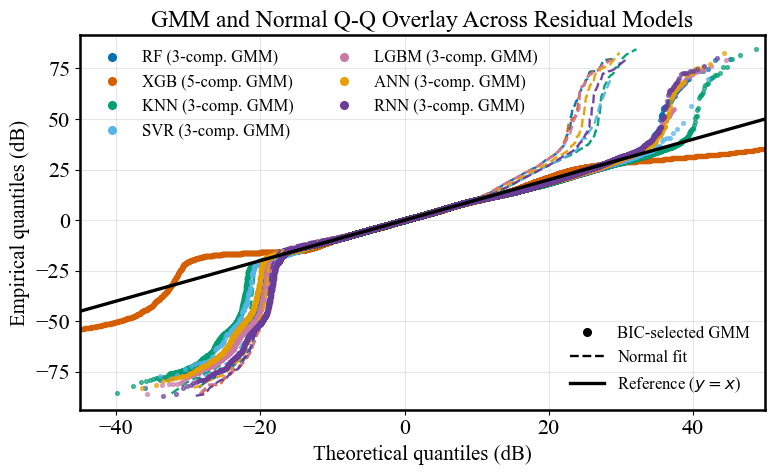

In [14]:
# Overlay all BIC-selected GMM Q-Q plots on one shared axis.
# Uses the same full-residual quantile approach as the individual Q-Q panels.

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
})

OVERLAY_MODEL_COLORS = {
    "RF":   "#0072B2",  # blue
    "XGB":  "#D55E00",  # vermillion
    "KNN":  "#009E73",  # green
    "SVR":  "#56B4E9",  # sky blue
    "LGBM": "#CC79A7",  # magenta
    "ANN":  "#E69F00",  # orange
    "RNN":  "#6A3D9A",  # deep purple
}

OVERLAY_QQ_MARKER_SIZE = 5.5
OVERLAY_QQ_ALPHA = 0.65
NORMAL_QQ_LINEWIDTH = 1.7
NORMAL_QQ_ALPHA = 0.95

fig, ax = plt.subplots(figsize=(8, 5))
global_min = np.inf
global_max = -np.inf
model_handles = []

for model_name in MODEL_ORDER:
    state = analysis_by_model[model_name]
    res = state["res"]
    sorted_residuals = state["sorted_residuals"]
    probabilities = state["probabilities"]
    color = OVERLAY_MODEL_COLORS.get(model_name, "#111827")

    x_grid = np.linspace(res.min(), res.max(), GMM_QQ_GRID_POINTS)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, state["best_gmm"]))
    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]

    ppf_func = interp1d(
        unique_cdf,
        unique_x,
        bounds_error=False,
        fill_value=(x_grid[0], x_grid[-1]),
    )
    theoretical_gmm_q = ppf_func(probabilities)
    theoretical_normal_q = state["normal_dist"].ppf(probabilities)

    ax.plot(
        theoretical_gmm_q,
        sorted_residuals,
        linestyle="None",
        marker=".",
        markersize=OVERLAY_QQ_MARKER_SIZE,
        color=color,
        alpha=OVERLAY_QQ_ALPHA,
        rasterized=True,
    )

    ax.plot(
        theoretical_normal_q,
        sorted_residuals,
        linestyle="--",
        linewidth=NORMAL_QQ_LINEWIDTH,
        color=color,
        alpha=NORMAL_QQ_ALPHA,
    )

    model_handles.append(
        Line2D(
            [0], [0],
            marker=".",
            linestyle="None",
            color=color,
            markersize=11,
            label=f"{model_name} ({state['best_gmm_display_name']})",
        )
    )

    global_min = min(global_min, theoretical_gmm_q.min(), theoretical_normal_q.min(), sorted_residuals.min())
    global_max = max(global_max, theoretical_gmm_q.max(), theoretical_normal_q.max(), sorted_residuals.max())

pad = 0.04 * (global_max - global_min)
plot_min = global_min - pad
plot_max = global_max + pad

reference_handle = ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="black",
    linestyle="-",
    linewidth=2.4,
    label=r"Reference ($y=x$)",
)[0]

style_handles = [
    Line2D([0], [0], marker=".", linestyle="None", color="black", markersize=11, label="BIC-selected GMM"),
    Line2D([0], [0], linestyle="--", color="black", linewidth=NORMAL_QQ_LINEWIDTH, label="Normal fit"),
    reference_handle,
]

ax.set_xlim(-45, 50)
ax.set_ylim(plot_min, plot_max)
ax.set_xlabel("Theoretical quantiles (dB)")
ax.set_ylabel("Empirical quantiles (dB)")
ax.set_title("GMM and Normal Q-Q Overlay Across Residual Models")
ax.grid(True, alpha=0.30)

model_legend = ax.legend(handles=model_handles, frameon=False, ncol=2, loc="upper left")
ax.add_artist(model_legend)
ax.legend(handles=style_handles, frameon=False, loc="lower right")

for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    spine.set_edgecolor("black")

plt.tight_layout()
# plt.savefig("Figures/qq_overlay_best_gmm_and_normal_multi_residuals.png", dpi=600, bbox_inches="tight")
plt.show()

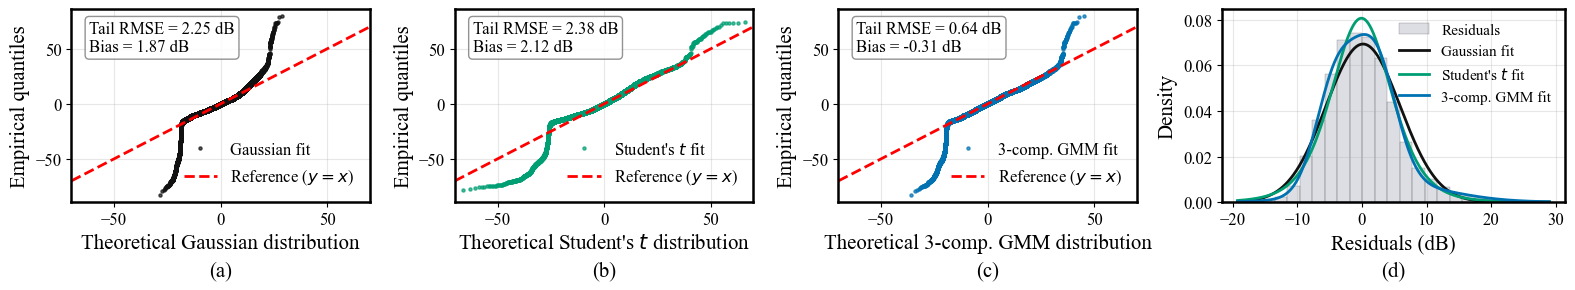

In [15]:
# RF-only 4-panel plot: Gaussian Q-Q, Student's t Q-Q, 3-GMM Q-Q, and density overlays.

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

MODEL_NAME = "RF"
GAUSSIAN_COLOR = "#111111"
STUDENT_T_COLOR = "#009E73"
GMM_COLOR = "#0072B2"
REFERENCE_COLOR = "red"
HIST_COLOR = "#9ca3af"
QQ_MARKER_SIZE = 4.5
SHARED_XLIM = (-70, 70)

def add_tail_error_box(ax, model_name, distribution_name, pos=(0.06, 0.94)):
    row = qq_tail_error_table[
        (qq_tail_error_table["Model"] == model_name)
        & (qq_tail_error_table["distribution"] == distribution_name)
        & (qq_tail_error_table["tail"] == "both")
    ]

    if row.empty:
        return

    row = row.iloc[0]
    txt = f"Tail RMSE = {row['tail_rmse']:.2f} dB\nBias = {row['tail_bias']:.2f} dB"

    ax.text(
        pos[0], pos[1], txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.5", alpha=0.85),
        zorder=10,
    )

state = analysis_by_model[MODEL_NAME]
res = state["res"]
sorted_residuals = state["sorted_residuals"]
probabilities = state["probabilities"]
gmm_3 = state["gmm_models_by_component"][3]

x_grid = np.linspace(res.min(), res.max(), GMM_QQ_GRID_POINTS)
cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, gmm_3))
unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_idx]
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))

theoretical_gaussian_q = state["normal_dist"].ppf(probabilities)
theoretical_t_q = state["t_dist"].ppf(probabilities)
theoretical_gmm_q = ppf_func(probabilities)

y_pad = 0.04 * (res.max() - res.min())
shared_ylim = (res.min() - y_pad, res.max() + y_pad)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), gridspec_kw={"width_ratios": [1, 1, 1, 1.15]})

qq_specs = [
    (axes[0], theoretical_gaussian_q, GAUSSIAN_COLOR, "Gaussian fit", "Normal", "Theoretical Gaussian distribution"),
    (axes[1], theoretical_t_q, STUDENT_T_COLOR, "Student's $t$ fit", "StudentT", "Theoretical Student's $t$ distribution"),
    (axes[2], theoretical_gmm_q, GMM_COLOR, "3-comp. GMM fit", "GMM(K=3)", "Theoretical 3-comp. GMM distribution"),
]

for ax, theoretical_q, color, label, table_name, xlabel in qq_specs:
    ax.plot(theoretical_q, sorted_residuals, linestyle="None", marker=".", markersize=QQ_MARKER_SIZE, color=color, alpha=0.70, rasterized=True, label=label)
    ax.plot(SHARED_XLIM, SHARED_XLIM, color=REFERENCE_COLOR, linestyle="--", linewidth=2.0, label=r"Reference ($y=x$)")
    ax.set_xlim(SHARED_XLIM)
    ax.set_ylim(shared_ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Empirical quantiles")
    ax.grid(True, alpha=0.30)
    add_tail_error_box(ax, MODEL_NAME, table_name, pos=(0.06, 0.94))
    ax.legend(frameon=False, loc="lower right", fontsize=12)

x_min, x_max = np.quantile(res, [0.001, 0.999])
x_pad = 0.08 * (x_max - x_min)
x_vals = np.linspace(x_min - x_pad, x_max + x_pad, 1200)

axes[3].hist(res, bins=25, range=(x_vals.min(), x_vals.max()), density=True, color=HIST_COLOR, alpha=0.35, edgecolor="black", linewidth=0.35, label="Residuals")
axes[3].plot(x_vals, state["normal_dist"].pdf(x_vals), color=GAUSSIAN_COLOR, linewidth=2.0, label="Gaussian fit")
axes[3].plot(x_vals, state["t_dist"].pdf(x_vals), color=STUDENT_T_COLOR, linewidth=2.0, label="Student's $t$ fit")
axes[3].plot(x_vals, np.exp(gmm_3.score_samples(x_vals.reshape(-1, 1))), color=GMM_COLOR, linewidth=2.0, label="3-comp. GMM fit")
axes[3].set_xlabel("Residuals (dB)")
axes[3].set_ylabel("Density")
axes[3].grid(True, alpha=0.30)
axes[3].legend(frameon=False, loc="upper right")

SUBPLOT_LABELS = ["(a)", "(b)", "(c)", "(d)"]

for ax, subplot_label in zip(axes, SUBPLOT_LABELS):
    ax.text(0.5, -0.30, subplot_label, transform=ax.transAxes, ha="center", va="top", fontsize=15, fontweight="normal")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_edgecolor("black")

plt.tight_layout(rect=[0, 0.01, 1, 1], w_pad=1.0)

os.makedirs("Figures", exist_ok=True)
plt.savefig("Figures/rf_qq_and_density_four_panel.png", dpi=600, bbox_inches="tight")
plt.show()